### Feature importance

The SR model searches over 94 candidate features (CH parameter lags + persistence speeds) and PySR selected a specific combination for the published formula: `A_CH60_193_lag4`, `P_CH30_211_lag4`, `speed_p27`.

This notebook checks that choice against two independent, model-agnostic feature-ranking methods:
1. **F-test** (`sklearn.feature_selection.f_regression`) — linear correlation strength
2. **Mutual information** (`sklearn.feature_selection.mutual_info_regression`) — captures nonlinear dependence too

If the formula's features rank highly under both, that's independent evidence PySR picked genuinely informative features rather than an arbitrary combination.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PHASES = ["rising", "maximum", "declining", "minimum"]
TARGET_FEATURES = ["A_CH60_193_lag4", "P_CH30_193_lag4", "P_CH30_211_lag4", "speed_p27", "accel_term"]

dfs = []
for phase in PHASES:
    csv_path = os.path.abspath(f"../data/processed/SR_training_{phase}.csv")
    dfs.append(pd.read_csv(csv_path, parse_dates=["datetime"]))

# "entire" is not committed to git (206MB, exceeds GitHub's limit) but is the exact
# row-wise union of the four phase files above, so we reconstruct it here instead.
df = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
df = df.dropna().reset_index(drop=True)


def select_feature_columns(df):
    """CH parameter lag features + persistence speed features (matches scripts/03_run_sr_model.py)."""
    feature_cols = []
    for col in df.columns:
        if col in ["datetime", "speed", "hss_event"]:
            continue
        if re.search(r"_lag\d", col) or col.startswith("speed_p") or re.match(r"^cr_prev\d+_", col):
            feature_cols.append(col)
    return feature_cols


feature_cols = select_feature_columns(df)

# Train only (Jan-Sep), matching scripts/03_run_sr_model.py's train/test split
train_mask = df["datetime"].dt.month.between(1, 9)
X_train = df.loc[train_mask, feature_cols].copy()
y_train = df.loc[train_mask, "speed"]

# Engineered interaction term matching the published formula's acceleration component:
# individual A_CH/P_CH rank only tells us about their marginal (univariate) relationship
# with speed; the formula actually uses their product, which can carry more signal than
# either factor alone.
X_train["accel_term"] = np.sqrt(X_train["A_CH60_193_lag4"] * X_train["P_CH30_211_lag4"])

print(f"{len(X_train.columns)} candidate features ({len(feature_cols)} raw + 1 engineered), "
      f"{len(X_train):,} training rows")


def plot_ranking(ranking, title, top_n=20):
    fig, ax = plt.subplots(figsize=(9, 7))
    top = ranking.head(top_n)[::-1]
    colors = ["tab:red" if c in TARGET_FEATURES else "tab:blue" for c in top.index]
    ax.barh(top.index, top.values, color=colors)
    ax.set_title(f"{title}  (red = published formula's features)", fontsize=13)
    ax.tick_params(labelsize=9)
    plt.tight_layout()
    plt.show()


def print_target_ranks(ranking, label):
    print(f"\n[{label}] rank of published-formula features (out of {len(ranking)}):")
    for f in TARGET_FEATURES:
        rank = ranking.index.get_loc(f) + 1
        print(f"  {f:20s}  rank {rank:3d} / {len(ranking)}  (score={ranking[f]:.4g})")

109 candidate features (108 raw + 1 engineered), 52,691 training rows


---

#### 1. F-test (linear correlation strength)


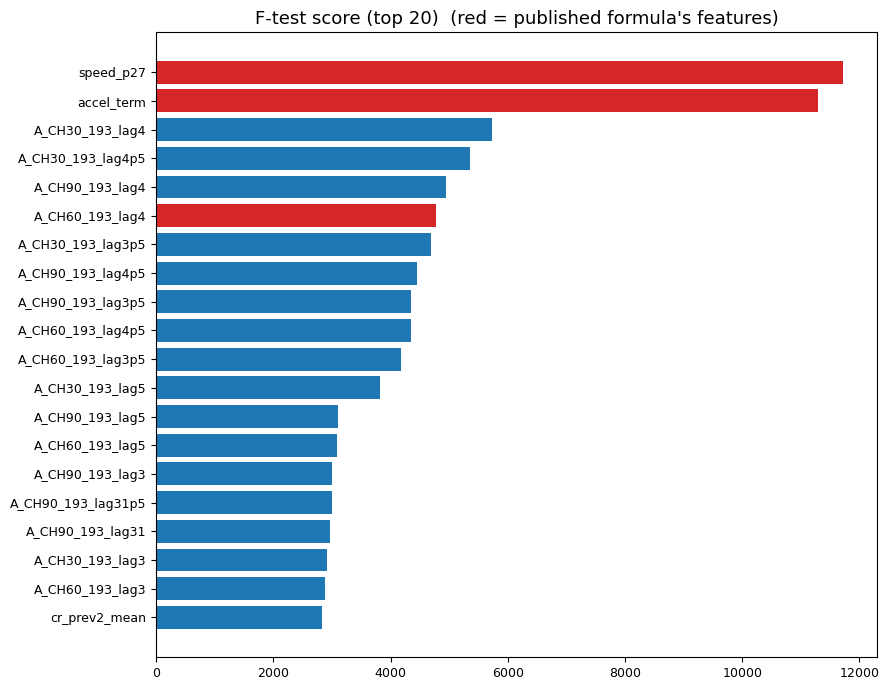


[F-test] rank of published-formula features (out of 109):
  A_CH60_193_lag4       rank   6 / 109  (score=4768)
  P_CH30_193_lag4       rank  41 / 109  (score=1318)
  P_CH30_211_lag4       rank  60 / 109  (score=603.2)
  speed_p27             rank   1 / 109  (score=1.171e+04)
  accel_term            rank   2 / 109  (score=1.129e+04)


In [2]:
from sklearn.feature_selection import f_regression

f_scores, _ = f_regression(X_train, y_train)
f_ranking = pd.Series(f_scores, index=X_train.columns).sort_values(ascending=False)

plot_ranking(f_ranking, "F-test score (top 20)")
print_target_ranks(f_ranking, "F-test")

---

#### 2. Mutual information (captures nonlinear dependence)


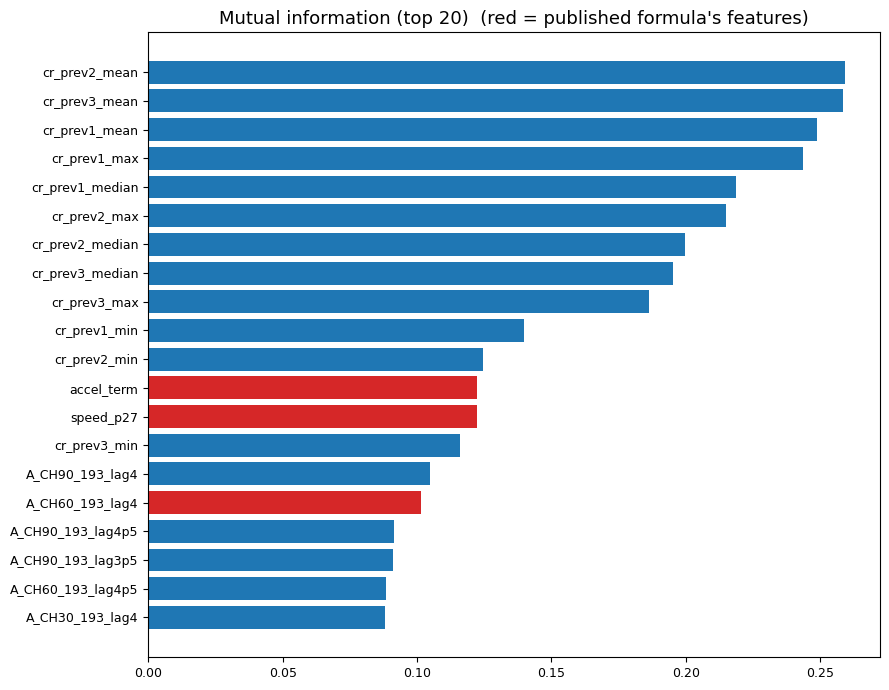


[Mutual information] rank of published-formula features (out of 109):
  A_CH60_193_lag4       rank  16 / 109  (score=0.1016)
  P_CH30_193_lag4       rank  55 / 109  (score=0.0701)
  P_CH30_211_lag4       rank  36 / 109  (score=0.07818)
  speed_p27             rank  13 / 109  (score=0.1223)
  accel_term            rank  12 / 109  (score=0.1224)


In [3]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_ranking = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

plot_ranking(mi_ranking, "Mutual information (top 20)")
print_target_ranks(mi_ranking, "Mutual information")

---

#### 3. Summary

Side-by-side ranks for the published formula's features under both methods.

In [4]:
summary = pd.DataFrame({
    "F-test rank": [f_ranking.index.get_loc(f) + 1 for f in TARGET_FEATURES],
    "Mutual info rank": [mi_ranking.index.get_loc(f) + 1 for f in TARGET_FEATURES],
}, index=TARGET_FEATURES)
summary["n_features"] = len(X_train.columns)
summary

,F-test rank,Mutual info rank,n_features
A_CH60_193_lag4,6,16,109
P_CH30_193_lag4,41,55,109
P_CH30_211_lag4,60,36,109
speed_p27,1,13,109
accel_term,2,12,109
